In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv('creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.3, random_state=42)

LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred_lr = LR.predict(X_test)

RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)
y_pred_rf = RF.predict(X_test)

print("Logistic Regression:-")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_lr) * 100:.2f}%")

print("\nRandom Forest:-")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_rf) * 100:.2f}%")

Logistic Regression:-
Accuracy: 98.03%
Precision: 99.11%
Recall: 96.94%
F1-Score: 98.01%

Random Forest:-
Accuracy: 99.99%
Precision: 99.98%
Recall: 100.00%
F1-Score: 99.99%


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('train.csv')

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])
  else:
    df[col] = df[col].fillna(df[col].median())

df = pd.get_dummies(df, drop_first=True)

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

LR = LinearRegression()
ModelLR = LR.fit(x_train, y_train)
PredictionLR = ModelLR.predict(x_test)

print('Linear Regression:-')
print(f"MAE: {mean_absolute_error(y_test, PredictionLR):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, PredictionLR)):.2f}")
print("\nPredicted vs Actual (first 10):")
comparison_lr = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': PredictionLR[:10].round(2)})
print(comparison_lr.to_string(index=False))

DT = DecisionTreeRegressor(random_state=42)
ModelDT = DT.fit(x_train, y_train)
PredictionDT = ModelDT.predict(x_test)

print('\nDecision Tree Regressor:-')
print(f"MAE: {mean_absolute_error(y_test, PredictionDT):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, PredictionDT)):.2f}")
print("\nPredicted vs Actual (first 10):")
comparison_dt = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': PredictionDT[:10].round(2)})
print(comparison_dt.to_string(index=False))

Linear Regression:-
MAE: 19460.04
RMSE: 43218.94

Predicted vs Actual (first 10):
 Actual  Predicted
 154500  157445.49
 325000  357285.16
 115000   83666.56
 159000  178128.44
 315500  322182.76
  75500   68645.25
 311500  236152.58
 146000  147153.24
  84500   57023.90
 135500  154050.68

Decision Tree Regressor:-
MAE: 26098.03
RMSE: 40985.37

Predicted vs Actual (first 10):
 Actual  Predicted
 154500   135000.0
 325000   316600.0
 115000   120000.0
 159000   157500.0
 315500   350000.0
  75500    81000.0
 311500   174500.0
 146000   148000.0
  84500    85500.0
 135500   135000.0


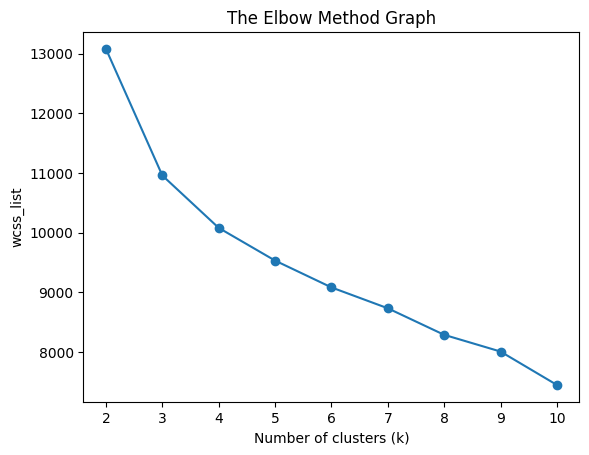

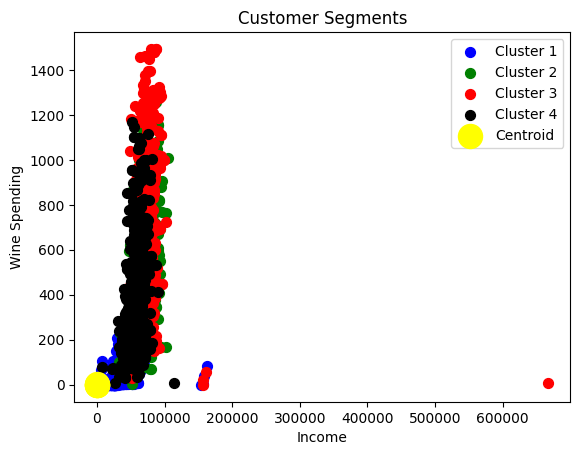

         ID   Income  MntWines  MntMeatProducts  Cluster
0      5524  58138.0       635              546        1
1      2174  46344.0        11                6        0
2      4141  71613.0       426              127        3
3      6182  26646.0        11               20        0
4      5324  58293.0       173              118        3
...     ...      ...       ...              ...      ...
2235  10870  61223.0       709              182        1
2236   4001  64014.0       406               30        3
2237   7270  56981.0       908              217        2
2238   8235  69245.0       428              214        2
2239   9405  52869.0        84               61        0

[2240 rows x 5 columns]


In [8]:
import pandas as pd
import matplotlib.pyplot as mtp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('marketing_campaign.csv', sep='\t')

features = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_model = df[features].copy()

df_model = df_model.fillna(df_model.median())

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_model)

wcss_list = []
for i in range(2, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x_scaled)
  wcss_list.append(kmeans.inertia_)

mtp.plot(range(2, 11), wcss_list, marker='o')
mtp.title('The Elbow Method Graph')
mtp.xlabel('Number of clusters (k)')
mtp.ylabel('wcss_list')
mtp.show()

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(x_scaled)
df['Cluster'] = y_predict

colors = ['blue', 'green', 'red', 'black']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(4):
  mtp.scatter(
      df_model['Income'][y_predict == i],
      df_model['MntWines'][y_predict == i],
      s=50, c=colors[i], label=labels[i]
  )
mtp.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroid')
mtp.title('Customer Segments')
mtp.xlabel('Income')
mtp.ylabel('Wine Spending')
mtp.legend()
mtp.show()

print(df[['ID', 'Income', 'MntWines', 'MntMeatProducts', 'Cluster']])